In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dataset-for-infosys/label_encoders (1).pkl
/kaggle/input/dataset-for-infosys/loan_xgboost_model (1).pkl
/kaggle/input/dataset-for-infosys/loan_applicants_dataset.csv


In [5]:
!pip install shap==0.41.0 xgboost==1.7.2


^C


In [10]:
!pip install gdown

# Replace <file_id> with your Google Drive file ID
!gdown --id <file_id_for_model>
!gdown --id <file_id_for_encoders>


/bin/bash: -c: line 1: syntax error near unexpected token `newline'
/bin/bash: -c: line 1: `gdown --id <file_id_for_model>'
/bin/bash: -c: line 1: syntax error near unexpected token `newline'
/bin/bash: -c: line 1: `gdown --id <file_id_for_encoders>'


In [7]:
import joblib

# Replace with your actual dataset folder name in Kaggle
model_path = '/kaggle/input/dataset-for-infosys/loan_xgboost_model (1).pkl'
encoders_path = '/kaggle/input/dataset-for-infosys/label_encoders (1).pkl'

# Load model and encoders
model = joblib.load(model_path)
encoders = joblib.load(encoders_path)

print("✅ Model and encoders loaded successfully!")


✅ Model and encoders loaded successfully!


Trying to unpickle estimator LabelEncoder from version 1.7.2 when using version 1.2.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


   Age  Monthly_Income  Credit_Score  Predicted_Probability  \
0   28           60000           750               0.999970   
1   45           35000           610               0.000044   

   Loan_Approved_Prediction  
0                         1  
1                         0  


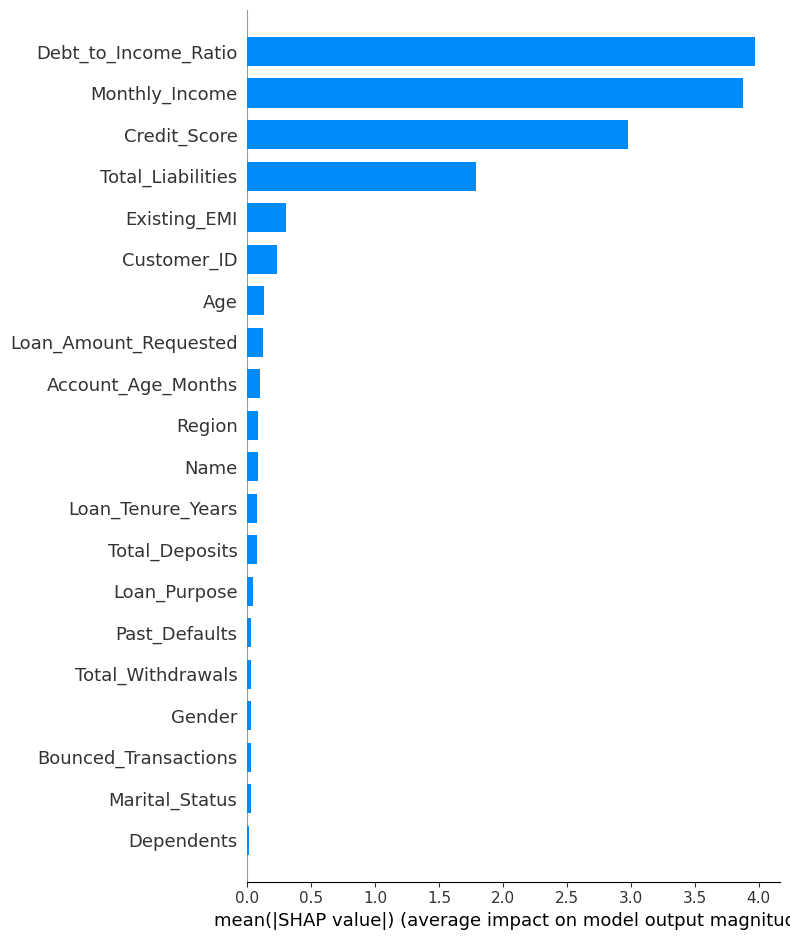

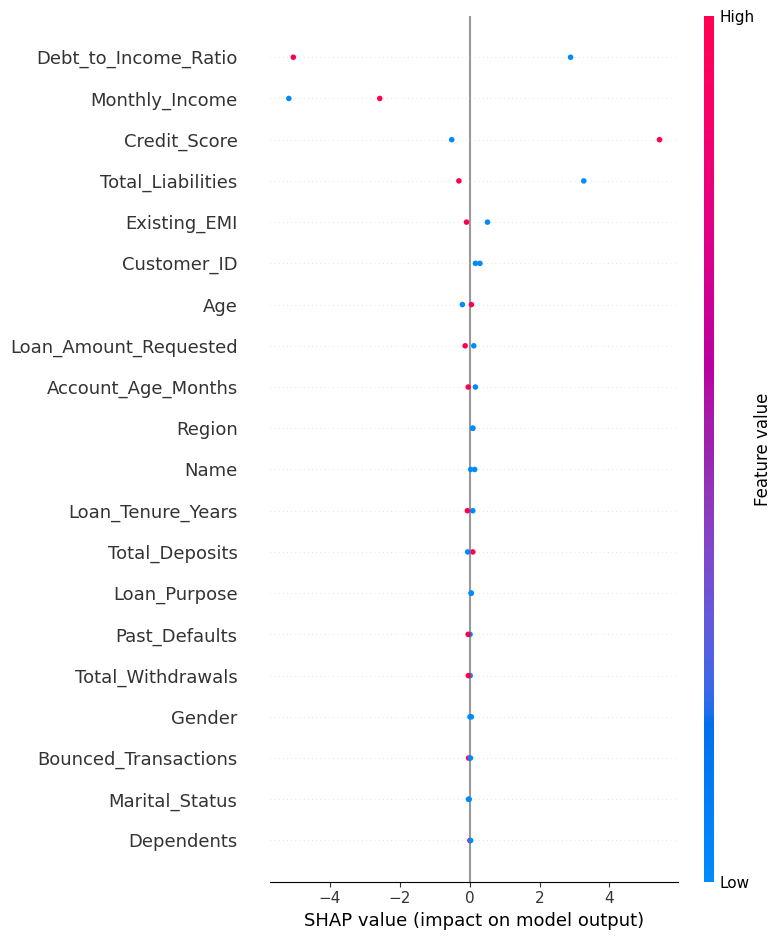

In [12]:
# =========================
# 1️⃣ Imports
# =========================
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# =========================
# 2️⃣ Load Model & Encoders
# =========================
# Change these paths to your Kaggle dataset paths
model_path = '/kaggle/input/dataset-for-infosys/loan_xgboost_model (1).pkl'
encoders_path = '/kaggle/input/dataset-for-infosys/label_encoders (1).pkl'

model = joblib.load(model_path)
encoders = joblib.load(encoders_path)

# =========================
# 3️⃣ Prepare New Applicants
# =========================
new_applicants = pd.DataFrame([
    {
        "Age": 28, "Gender": "M", "Marital_Status": "Single", "Employment_Type": "Job",
        "Monthly_Income": 60000, "Loan_Amount_Requested": 400000, "Credit_Score": 750,
        "Existing_EMI": 10000, "Loan_Tenure_Years": 5, "Dependents": 1,
        "Bank_Statement_Verified": "Yes", "Voice_Verified": "Yes", "Document_Verified": "Yes",
        "Total_Liabilities": 50000, "Past_Defaults": 0, "Region": "Delhi", "Loan_Purpose": "Home",
        "Total_Withdrawals": 200000, "Total_Deposits": 250000, "Avg_Balance": 40000,
        "Bounced_Transactions": 0, "Account_Age_Months": 36,
        "Salary_Credit_Frequency": "Monthly", "Bank_Verified": "Yes",
        "Debt_to_Income_Ratio": 0.17
    },
    {
        "Age": 45, "Gender": "F", "Marital_Status": "Married", "Employment_Type": "Self-employed",
        "Monthly_Income": 35000, "Loan_Amount_Requested": 700000, "Credit_Score": 610,
        "Existing_EMI": 18000, "Loan_Tenure_Years": 7, "Dependents": 3,
        "Bank_Statement_Verified": "No", "Voice_Verified": "No", "Document_Verified": "No",
        "Total_Liabilities": 400000, "Past_Defaults": 2, "Region": "Mumbai", "Loan_Purpose": "Business",
        "Total_Withdrawals": 350000, "Total_Deposits": 300000, "Avg_Balance": 15000,
        "Bounced_Transactions": 3, "Account_Age_Months": 24,
        "Salary_Credit_Frequency": "Irregular", "Bank_Verified": "No",
        "Debt_to_Income_Ratio": 0.51
    }
])

# =========================
# 4️⃣ Encode Categorical Columns
# =========================
cat_cols = ["Gender","Marital_Status","Employment_Type","Bank_Statement_Verified",
            "Voice_Verified","Document_Verified","Region","Loan_Purpose",
            "Salary_Credit_Frequency","Bank_Verified"]

for col in cat_cols:
    if col in new_applicants.columns:
        le = encoders[col]  # use the saved encoder
        # Handle unseen categories by mapping them to -1
        new_applicants[col] = new_applicants[col].map(lambda x: x if x in le.classes_ else 'Unknown')
        # Add 'Unknown' to classes if needed
        if 'Unknown' not in le.classes_:
            le.classes_ = np.append(le.classes_, 'Unknown')
        new_applicants[col] = le.transform(new_applicants[col])

# =========================
# 5️⃣ Add Placeholder Columns for Model Alignment
# =========================
model_features = model.get_booster().feature_names

for col in ['Customer_ID', 'Name']:
    if col not in new_applicants.columns:
        new_applicants[col] = 0  # placeholder

# Reorder columns exactly as model expects
predict_data = new_applicants[model_features]

# =========================
# 6️⃣ Make Predictions
# =========================
pred_probs = model.predict_proba(predict_data)[:, 1]
pred_labels = model.predict(predict_data)

new_applicants["Predicted_Probability"] = pred_probs
new_applicants["Loan_Approved_Prediction"] = pred_labels

print(new_applicants[["Age","Monthly_Income","Credit_Score","Predicted_Probability","Loan_Approved_Prediction"]])

# =========================
# 7️⃣ SHAP Explanations
# =========================
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(predict_data)

# Summary plot
shap.summary_plot(shap_values, predict_data, plot_type="bar")
shap.summary_plot(shap_values, predict_data)
